# V-JEPA 2 — Fine-tuning

## Demo Data

To facilitate quick testing without high computational cost, the `data_demo` folder is included. This reduced subset has:

- Fewer classes (not all 11 original ones).
- Fewer videos per class.
- Small total size, allowing the full pipeline to run in minutes even on CPU.

Link: https://www.kaggle.com/datasets/sharjeelmazhar/human-activity-recognition-video-dataset

**Usage:**
Modify the `data_root` variable in the notebook to point to `data_demo`. The rest of the code works without changes.

---

### V-JEPA2 Structure
1. Installation and dependencies
2. Imports and global configuration
3. Automatic dataset split
4. Dataset and DataLoaders
5. Model loading
6. Training with TensorBoard
7. Complete evaluation on test
8. Confusion matrix and per-class metrics

---

## Note on Embeddings

Neither the notebook nor the generated files include explicit extraction of feature vectors (embeddings) from the original dataset. If vector representations are required (e.g., for similarity search or clustering), the notebook can be easily adapted to return the *encoder* output before the classification layer (a 768-dimensional vector).

## Minimum Requirements

- PyTorch >= 2.0
- TorchVision
- OpenCV
- NumPy, Pandas, Matplotlib, tqdm

### Download Models

Use: `pip install -U git+https://github.com/huggingface/transformers`

- ### vjepa2_1: https://dl.fbaipublicfiles.com/vjepa2/vjepa2_1_vitb_dist_vitG_384.pt


In [ ]:
# !pip install -U git+https://github.com/huggingface/transformers


---
## Imports and Global Configuration


In [1]:
import os, sys, pathlib, random, shutil, time, warnings, json
from concurrent.futures import ProcessPoolExecutor, as_completed
import subprocess
warnings.filterwarnings("ignore")

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from functools import partial

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import Image as IPImage, display, clear_output

from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, precision_score, recall_score
)

from transformers import (
    VJEPA2ForVideoClassification,
    VJEPA2VideoProcessor,
)
from torchcodec.decoders import VideoDecoder
from torchcodec.samplers import clips_at_random_indices
from torchvision.transforms import v2
from torch.utils.tensorboard import SummaryWriter

# ── Configuración global ──────────────────────────────────────────────────
#ref: https://github.com/facebookresearch/vjepa2
# facebook/vjepa2-vitl-fpc64-256
# facebook/vjepa2-vitl-fpc16-256-ssv2
# vjepa2_1_vit_base_384


CFG = {
    # Modelo
    "model_name": "facebook/vjepa2-vitl-fpc64-256",

    # Dataset
    "data_root": "HAR_data",
    "video_ext": "mp4",

    # Entrenamiento
    "num_epochs": 30,
    "batch_size": 4,
    "accum_steps": 8,
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "num_workers": 4,
    "freeze_backbone": True,
    "frames_per_clip": 32,
    "patience": 5,
    # Salidas
    "output_dir": "vjepa2_output_32",
    "checkpoint_best": "vjepa2_output_32/best_model",
    "log_dir": "vjepa2_output_32/runs",
}
os.makedirs(CFG["output_dir"], exist_ok=True)
os.makedirs(CFG["log_dir"], exist_ok=True)
os.makedirs(CFG["checkpoint_best"], exist_ok=True)
os.makedirs(os.path.join(CFG["checkpoint_best"], "checkpoint"), exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"{'='*55}")
print(f"  Device : {DEVICE}")
if DEVICE == "cuda":
    print(f"  GPU    : {torch.cuda.get_device_name(0)}")
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    free  = torch.cuda.mem_get_info()[0] / 1e9
    print(f"  VRAM   : {free:.1f} GB libres / {total:.1f} GB total")
print(f"  PyTorch: {torch.__version__}")
print(f"{'='*55}")

  Device : cuda
  GPU    : NVIDIA GeForce RTX 3060
  VRAM   : 12.0 GB libres / 12.5 GB total
  PyTorch: 2.10.0+cu128


---
## Automatic Dataset Split

If the `data` folder contains class folders directly (without train/val/test split), this cell automatically splits the data. If already split, it detects this and skips the splitting step.


In [2]:
def get_video_metadata_fast(path):
    try:
        cmd = [
            "ffprobe", "-v", "error",
            "-select_streams", "v:0",
            "-show_entries", "stream=width,height",
            "-show_entries", "format=duration",
            "-of", "json",
            str(path)
        ]

        result = subprocess.run(cmd, capture_output=True, text=True)
        data = json.loads(result.stdout)

        duration = float(data["format"]["duration"])
        stream = data["streams"][0]

        width = int(stream["width"])
        height = int(stream["height"])

        return path, duration, width, height

    except:
        return path, None, None, None

In [3]:
def is_valid_fast(meta, min_duration=3, min_resolution=112):
    if meta is None:
        return False

    path, duration, w, h = meta

    if duration is None or w is None or h is None:
        return False

    if duration < min_duration:
        return False

    if min(w, h) < min_resolution:
        return False

    return True

In [4]:
def trim_video_task_fast(args):
    src_path, dst_path, max_seconds = args
    try:
        cmd = [
            "ffmpeg", "-y",
            "-i", str(src_path),
            "-t", str(max_seconds),
            "-c", "copy",   # MUCHO más rápido
            str(dst_path)
        ]

        result = subprocess.run(
            cmd,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL
        )

        # si falló → eliminar archivo corrupto
        if result.returncode != 0 and dst_path.exists():
            dst_path.unlink()

    except:
        pass

In [5]:
def split_dataset(
    data_root,
    video_ext="mp4",
    seed=42,
    max_train=40,
    max_val=20,
    max_test=40,
    num_workers=4
):

    root = pathlib.Path(data_root)
    splits = ["train", "val", "test"]

    # =========================
    # DETECTAR SI YA EXISTE SPLIT
    # =========================
    split_paths = [root / s for s in splits]

    if all(p.exists() for p in split_paths):

        print("\n[INFO] Dataset ya dividido — mostrando resumen\n")

        summary = {}

        for split in splits:
            for cls_dir in (root / split).iterdir():
                if not cls_dir.is_dir():
                    continue

                cls = cls_dir.name
                count = len(list(cls_dir.glob(f"*.{video_ext}")))

                if cls not in summary:
                    summary[cls] = {"train": 0, "val": 0, "test": 0}

                summary[cls][split] = count

        # =========================
        # PRINT RESUMEN
        # =========================
        print(f"{'Clase':<25} {'Train':>6} {'Val':>6} {'Test':>6}")
        print("-" * 50)

        for cls, c in summary.items():
            print(f"{cls:<25} {c['train']:>6} {c['val']:>6} {c['test']:>6}")

        print("\nNo se procesó nada (ya estaba dividido)")
        return

    # =========================
    # SI NO EXISTE → PROCESAR NORMAL
    # =========================
    print("\n[INFO] No hay split, procesando dataset...\n")

    classes = [
        d.name for d in root.iterdir()
        if d.is_dir() and d.name not in splits
    ]

    if not classes:
        print("[WARN] No hay clases base para dividir")
        return

    random.seed(seed)
    summary = {}

    print(f"Modo TURBO con {num_workers} workers")

    for cls in classes:
        print(f"\nProcesando: {cls}")

        all_videos = list((root / cls).glob(f"*.{video_ext}"))

        metas = []
        with ProcessPoolExecutor(max_workers=num_workers) as ex:
            futures = [ex.submit(get_video_metadata_fast, v) for v in all_videos]
            for f in as_completed(futures):
                metas.append(f.result())

        valid_videos = []
        rejected = 0

        for m in metas:
            if is_valid_fast(m):
                valid_videos.append(m[0])
            else:
                rejected += 1

        random.shuffle(valid_videos)

        train_v = valid_videos[:max_train]
        val_v   = valid_videos[max_train:max_train + max_val]
        test_v  = valid_videos[max_train + max_val:max_train + max_val + max_test]

        buckets = {
            "train": train_v,
            "val": val_v,
            "test": test_v
        }

        summary[cls] = {
            "train": len(train_v),
            "val": len(val_v),
            "test": len(test_v),
            "rejected": rejected
        }

        tasks = []

        for split, vids in buckets.items():
            dest = root / split / cls
            dest.mkdir(parents=True, exist_ok=True)

            for v in vids:
                out_path = dest / v.name
                tasks.append((v, out_path, 15))

        with ProcessPoolExecutor(max_workers=num_workers) as ex:
            list(ex.map(trim_video_task_fast, tasks))

    # =========================
    # RESUMEN FINAL
    # =========================
    print(f"\n{'Clase':<20} {'Train':>6} {'Val':>6} {'Test':>6} {'Drop':>6}")
    print("-" * 52)

    for cls, c in summary.items():
        print(f"{cls:<20} {c['train']:>6} {c['val']:>6} {c['test']:>6} {c['rejected']:>6}")

    print("\nSplit ULTRA RÁPIDO completo")

In [6]:
split_dataset(CFG["data_root"], CFG["video_ext"])


[INFO] No hay split, procesando dataset...

Modo TURBO con 4 workers

Procesando: Standing Still

Procesando: Walking

Procesando: Picking Up Object

Procesando: Clapping

Procesando: Meet and Split

Procesando: null

Procesando: handshake

Procesando: Walking While Reading Book

Procesando: Sitting

Procesando: Walking While Using Phone

Procesando: Placing Object

Clase                 Train    Val   Test   Drop
----------------------------------------------------
Standing Still           40     20     40      0
Walking                  40     20     40      0
Picking Up Object        40     20     40      0
Clapping                 40     20     40      0
Meet and Split           40     20     40      0
null                     40     20     40      0
handshake                40     20     40      0
Walking While Reading Book     40     20     40      0
Sitting                  40     20     40      0
Walking While Using Phone     40     20     40      0
Placing Object           40

---
##  Dataset y DataLoaders

In [13]:
# =========================
# TRANSFORMS
# =========================

print("Cargando processor...")
processor = VJEPA2VideoProcessor.from_pretrained(CFG["model_name"])

H = processor.crop_size["height"]
W = processor.crop_size["width"]

print(f"Crop size: {H} x {W}")

train_tf = v2.Compose([
    v2.RandomResizedCrop((H, W), scale=(0.7, 1.0)),
    v2.RandomHorizontalFlip(),
    v2.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
])

eval_tf = v2.Compose([
    v2.CenterCrop((H, W))
])

Cargando processor...
Crop size: 256 x 256


In [14]:
class VideoDataset(Dataset):
    def __init__(self, video_paths, label2id):
        self.video_paths = video_paths
        self.label2id = label2id

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        path = self.video_paths[idx]
        label = path.parts[-2]

        try:
            decoder = VideoDecoder(str(path))
        except Exception as e:
            print(f"[WARN] {path.name}: {e}")
            return self.__getitem__((idx + 1) % len(self))

        return decoder, self.label2id[label]

In [15]:
def sample_uniform_frames(decoder, num_frames):
    """
    Muestreo uniforme simple (robusto y compatible).
    """
    total_frames = len(decoder)

    if total_frames <= 0:
        raise ValueError("Video sin frames")

    indices = np.linspace(0, total_frames - 1, num_frames).astype(int)
    frames = decoder.get_frames_at(indices).data  # (T, C, H, W)

    return frames

In [16]:
def collate_fn(samples, frames_per_clip, transforms):
    """
    Devuelve tensor con shape:
    (B, T, C, H, W)
    """
    videos, labels = [], []

    for decoder, lbl in samples:
        try:
            # LLAMADA CORRECTA
            clip = sample_uniform_frames(decoder, frames_per_clip)  # (T, C, H, W)

            # aplicar transform frame a frame (MUY IMPORTANTE)
            clip = torch.stack([transforms(frame) for frame in clip])

            videos.append(clip)
            labels.append(lbl)

        except Exception as e:
            print(f"[WARN] clip error: {e}")

    if not videos:
        dummy = torch.zeros(frames_per_clip, 3, 224, 224)
        return dummy.unsqueeze(0), torch.tensor([0])

    videos = torch.stack(videos)  # (B, T, C, H, W)

    return videos, torch.tensor(labels)

In [17]:
root = pathlib.Path(CFG["data_root"])

train_paths = sorted(root.glob(f"train/**/*.{CFG['video_ext']}"))
val_paths   = sorted(root.glob(f"val/**/*.{CFG['video_ext']}"))
test_paths  = sorted(root.glob(f"test/**/*.{CFG['video_ext']}"))

all_paths = train_paths + val_paths + test_paths

CLASS_NAMES = sorted({p.parts[-2] for p in all_paths})
LABEL2ID    = {lbl: i for i, lbl in enumerate(CLASS_NAMES)}
ID2LABEL    = {i: lbl for lbl, i in LABEL2ID.items()}

print("Clases:", CLASS_NAMES)

Clases: ['Clapping', 'Meet and Split', 'Picking Up Object', 'Placing Object', 'Sitting', 'Standing Still', 'Walking', 'Walking While Reading Book', 'Walking While Using Phone', 'handshake', 'null']


In [18]:
_collate = partial(collate_fn, frames_per_clip=CFG["frames_per_clip"])

train_loader = DataLoader(
    VideoDataset(train_paths, LABEL2ID),
    batch_size=CFG["batch_size"],
    shuffle=True,
    collate_fn=partial(_collate, transforms=train_tf),
    num_workers=CFG["num_workers"],
    pin_memory=True
)

val_loader = DataLoader(
    VideoDataset(val_paths, LABEL2ID),
    batch_size=CFG["batch_size"],
    shuffle=False,
    collate_fn=partial(_collate, transforms=eval_tf),
    num_workers=CFG["num_workers"],
    pin_memory=True
)

test_loader = DataLoader(
    VideoDataset(test_paths, LABEL2ID),
    batch_size=CFG["batch_size"],
    shuffle=False,
    collate_fn=partial(_collate, transforms=eval_tf),
    num_workers=CFG["num_workers"],
    pin_memory=True
)

print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

Train: 440 | Val: 220 | Test: 440


---
## Load Model with Classification Head for Our Classes


In [19]:
print(f"Cargando modelo: {CFG['model_name']}")
print(f"Clases: {CLASS_NAMES}")

model = VJEPA2ForVideoClassification.from_pretrained(
    CFG["model_name"],
    dtype=torch.float32,
    label2id=LABEL2ID,
    id2label=ID2LABEL,
    ignore_mismatched_sizes=True,   # reinicializa head con nuestras N clases
).to(DEVICE)

# Congelar backbone — solo entrenar el head
if CFG["freeze_backbone"]:
    for param in model.vjepa2.parameters():
        param.requires_grad = False

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen    = total - trainable

print(f"\n{'='*45}")
print(f"  Parámetros totales    : {total:>12,}")
print(f"  Backbone (congelado)  : {frozen:>12,}")
print(f"  Head (entrenable)     : {trainable:>12,}")
if DEVICE == "cuda":
    print(f"  VRAM usada            : {torch.cuda.memory_allocated()/1e9:>11.2f} GB")
    print(f"  VRAM libre            : {torch.cuda.mem_get_info()[0]/1e9:>11.2f} GB")
print(f"{'='*45}")

Cargando modelo: facebook/vjepa2-vitl-fpc64-256
Clases: ['Clapping', 'Meet and Split', 'Picking Up Object', 'Placing Object', 'Sitting', 'Standing Still', 'Walking', 'Walking While Reading Book', 'Walking While Using Phone', 'handshake', 'null']


Some weights of VJEPA2ForVideoClassification were not initialized from the model checkpoint at facebook/vjepa2-vitl-fpc64-256 and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.cross_attention_layer.cross_attn.k_proj.bias', 'pooler.cross_attention_layer.cross_attn.k_proj.weight', 'pooler.cross_attention_layer.cross_attn.q_proj.bias', 'pooler.cross_attention_layer.cross_attn.q_proj.weight', 'pooler.cross_attention_layer.cross_attn.v_proj.bias', 'pooler.cross_attention_layer.cross_attn.v_proj.weight', 'pooler.cross_attention_layer.layer_norm1.bias', 'pooler.cross_attention_layer.layer_norm1.weight', 'pooler.cross_attention_layer.layer_norm2.bias', 'pooler.cross_attention_layer.layer_norm2.weight', 'pooler.cross_attention_layer.mlp.fc1.bias', 'pooler.cross_attention_layer.mlp.fc1.weight', 'pooler.cross_attention_layer.mlp.fc2.bias', 'pooler.cross_attention_layer.mlp.fc2.weight', 'pooler.query_tokens', 'pooler.self_attention_layers.0.layer_norm1.bias', 'pooler.self


  Parámetros totales    :  375,318,923
  Backbone (congelado)  :  325,971,328
  Head (entrenable)     :   49,347,595
  VRAM usada            :        1.50 GB
  VRAM libre            :        9.52 GB


---
## Training with Early Stopping


In [20]:
def quick_eval(model, processor, loader, device):
    """Evaluación rápida — retorna accuracy y F1."""
    model.eval()
    preds_all, labels_all = [], []

    with torch.no_grad():
        for vids, labels in loader:
            # vids: (B, T, C, H, W)
            inputs = processor(list(vids), return_tensors="pt").to(device)
            labels = labels.to(device)

            logits = model(**inputs).logits

            preds_all.extend(logits.argmax(-1).cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    acc = accuracy_score(labels_all, preds_all)
    f1  = f1_score(labels_all, preds_all, average="weighted", zero_division=0)

    return acc, f1

In [21]:
trainable_params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.AdamW(
    trainable_params,
    lr=CFG["lr"],
    weight_decay=CFG["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CFG["num_epochs"]
)

writer = SummaryWriter(CFG["log_dir"])

In [22]:
history = {
    "train_loss": [],
    "val_acc": [],
    "val_f1": []
}

best_val_acc = -1.0
patience_cnt = 0
global_step  = 0

In [23]:
import time

print(f"{'='*55}")
print(f"  ENTRENAMIENTO — {CFG['num_epochs']} épocas máx.")
print(f"  Batch efectivo : {CFG['batch_size'] * CFG['accum_steps']}")
print(f"  LR inicial     : {CFG['lr']}")
print(f"  Early stopping : {CFG['patience']} épocas sin mejora")
print(f"{'='*55}\n")

for epoch in range(1, CFG["num_epochs"] + 1):

    model.train()
    running_loss = 0.0
    optimizer.zero_grad()

    start_epoch = time.time()

    for step, (vids, labels) in enumerate(train_loader, start=1):

        t0 = time.time()

        # DEBUG opcional (solo primeros steps)
        if step == 1:
            print(f"[DEBUG] vids shape: {vids.shape}")

        inputs = processor(list(vids), return_tensors="pt").to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(**inputs, labels=labels)
        loss    = outputs.loss / CFG["accum_steps"]

        loss.backward()
        running_loss += loss.item() * CFG["accum_steps"]

        if step % CFG["accum_steps"] == 0:
            torch.nn.utils.clip_grad_norm_(trainable_params, 1.0)
            optimizer.step()
            optimizer.zero_grad()
            global_step += 1

        # ── PRINT CADA N STEPS ─────────────────────
        if step % 5 == 0:
            t1 = time.time()
            print(
                f"Epoch {epoch} | Step {step}/{len(train_loader)} | "
                f"Loss: {running_loss/step:.4f} | "
                f"{(t1 - t0):.2f}s/step"
            )

    scheduler.step()
    avg_loss = running_loss / len(train_loader)

    epoch_time = time.time() - start_epoch

    # ── VALIDACIÓN ───────────────────────────────
    print("Validando...")
    val_acc, val_f1 = quick_eval(model, processor, val_loader, DEVICE)

    history["train_loss"].append(avg_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    writer.add_scalar("Val/Accuracy", val_acc, epoch)
    writer.add_scalar("Val/F1",       val_f1,  epoch)
    writer.add_scalar("LR", scheduler.get_last_lr()[0], epoch)

    flag = ""

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        model.save_pretrained(CFG["checkpoint_best"])
        processor.save_pretrained(CFG["checkpoint_best"])
        patience_cnt = 0
        flag = "  MEJOR"
    else:
        patience_cnt += 1

    print(
        f"\nEpoch {epoch:>3}/{CFG['num_epochs']} COMPLETA | "
        f"Loss: {avg_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val F1: {val_f1:.4f} | "
        f"Tiempo: {epoch_time:.1f}s | "
        f"Best: {best_val_acc:.4f}{flag}\n"
    )

    if patience_cnt >= CFG["patience"]:
        print(f"Early stopping: sin mejora por {CFG['patience']} épocas.")
        break

writer.close()

print(f"\nEntrenamiento completo | Mejor Val Acc: {best_val_acc:.4f}")
print(f"Modelo guardado en: {CFG['checkpoint_best']}")

  ENTRENAMIENTO — 30 épocas máx.
  Batch efectivo : 32
  LR inicial     : 0.0001
  Early stopping : 5 épocas sin mejora



[DEBUG] vids shape: torch.Size([4, 32, 3, 256, 256])
Epoch 1 | Step 5/110 | Loss: 2.3478 | 5.75s/step
Epoch 1 | Step 10/110 | Loss: 2.2535 | 5.83s/step
Epoch 1 | Step 15/110 | Loss: 2.5280 | 5.79s/step
Epoch 1 | Step 20/110 | Loss: 2.5700 | 5.91s/step
Epoch 1 | Step 25/110 | Loss: 2.5713 | 5.73s/step
Epoch 1 | Step 30/110 | Loss: 2.5387 | 5.71s/step
Epoch 1 | Step 35/110 | Loss: 2.4804 | 5.73s/step
Epoch 1 | Step 40/110 | Loss: 2.4278 | 5.76s/step
Epoch 1 | Step 45/110 | Loss: 2.4023 | 5.93s/step
Epoch 1 | Step 50/110 | Loss: 2.3653 | 5.87s/step
Epoch 1 | Step 55/110 | Loss: 2.3559 | 5.83s/step
Epoch 1 | Step 60/110 | Loss: 2.3218 | 5.76s/step
Epoch 1 | Step 65/110 | Loss: 2.2926 | 5.74s/step
Epoch 1 | Step 70/110 | Loss: 2.2397 | 5.88s/step
Epoch 1 | Step 75/110 | Loss: 2.2119 | 5.84s/step
Epoch 1 | Step 80/110 | Loss: 2.1645 | 5.74s/step
Epoch 1 | Step 85/110 | Loss: 2.1286 | 5.74s/step
Epoch 1 | Step 90/110 | Loss: 2.0847 | 5.78s/step
Epoch 1 | Step 95/110 | Loss: 2.0490 | 5.78s/ste

In [29]:
best_model = VJEPA2ForVideoClassification.from_pretrained(CFG["checkpoint_best"]).to(DEVICE)
best_processor = VJEPA2VideoProcessor.from_pretrained(CFG["checkpoint_best"])

---
## Training Curves


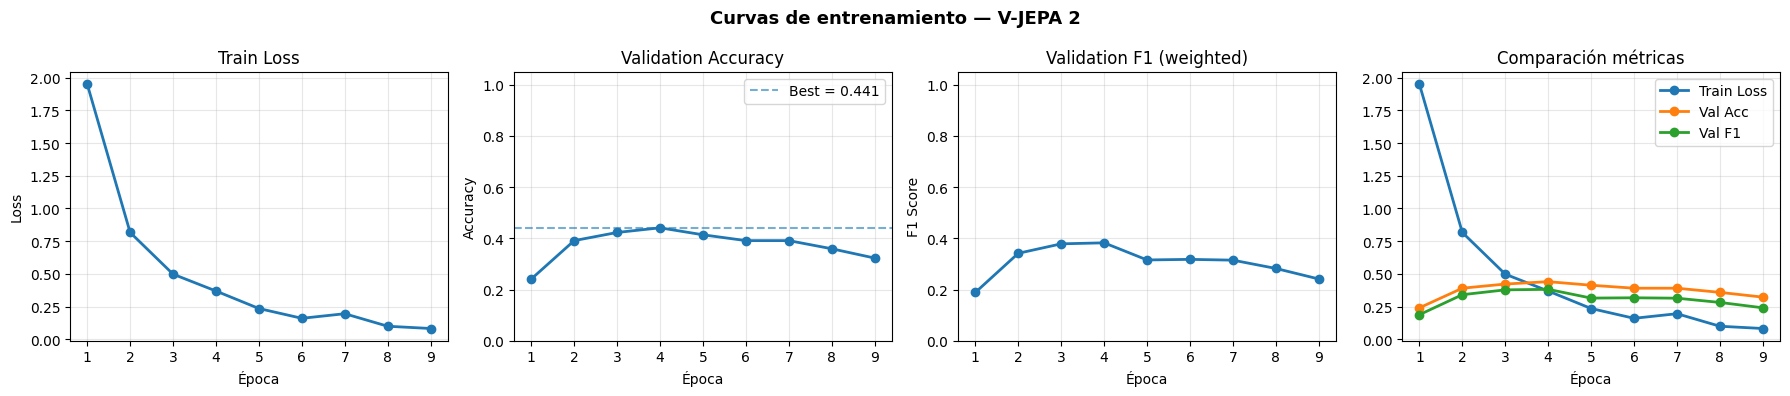

Guardado → vjepa2_output_32/training_curves.png


In [30]:
import os
import matplotlib.pyplot as plt

# ── Seguridad ─────────────────────────────────────────────
epochs_ran = len(history.get("train_loss", []))

if epochs_ran == 0:
    print("No hay datos en history")
else:
    xs = list(range(1, epochs_ran + 1))

    best_val_acc = max(history["val_acc"]) if len(history["val_acc"]) > 0 else 0

    os.makedirs(CFG["output_dir"], exist_ok=True)

    # ── FIGURA ─────────────────────────────────────────────
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle("Curvas de entrenamiento — V-JEPA 2", fontsize=13, fontweight="bold")

    # ── 1. TRAIN LOSS ─────────────────────────────────────
    axes[0].plot(xs, history["train_loss"], "o-", linewidth=2)
    axes[0].set_title("Train Loss")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)

    # ── 2. VAL ACCURACY ───────────────────────────────────
    axes[1].plot(xs, history["val_acc"], "o-", linewidth=2)
    axes[1].axhline(best_val_acc, linestyle="--", alpha=0.6,
                    label=f"Best = {best_val_acc:.3f}")
    axes[1].set_title("Validation Accuracy")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0, 1.05)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # ── 3. VAL F1 ─────────────────────────────────────────
    axes[2].plot(xs, history["val_f1"], "o-", linewidth=2)
    axes[2].set_title("Validation F1 (weighted)")
    axes[2].set_xlabel("Época")
    axes[2].set_ylabel("F1 Score")
    axes[2].set_ylim(0, 1.05)
    axes[2].grid(True, alpha=0.3)

    # ── 4. COMPARACIÓN (NORMALIZADA) ─────────────────────
    axes[3].plot(xs, history["train_loss"], "o-", label="Train Loss", linewidth=2)
    axes[3].plot(xs, history["val_acc"], "o-", label="Val Acc", linewidth=2)
    axes[3].plot(xs, history["val_f1"], "o-", label="Val F1", linewidth=2)

    axes[3].set_title("Comparación métricas")
    axes[3].set_xlabel("Época")
    axes[3].legend()
    axes[3].grid(True, alpha=0.3)

    # ── GUARDAR ──────────────────────────────────────────
    plt.tight_layout()
    curves_path = os.path.join(CFG["output_dir"], "training_curves.png")
    plt.savefig(curves_path, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Guardado → {curves_path}")

---
## Complete Evaluation on TEST SET



Evaluando en TEST set...

RESULTADOS TEST
Accuracy  : 0.3727
F1-score  : 0.3228
Precision : 0.3780
Recall    : 0.3727

Reporte por clase:
                            precision    recall  f1-score   support

                  Clapping       0.70      0.65      0.68        40
            Meet and Split       0.00      0.00      0.00        40
         Picking Up Object       0.00      0.00      0.00        40
            Placing Object       0.00      0.00      0.00        40
                   Sitting       1.00      0.30      0.46        40
            Standing Still       0.33      0.17      0.23        40
                   Walking       0.28      0.47      0.36        40
Walking While Reading Book       0.59      0.57      0.58        40
 Walking While Using Phone       0.74      0.35      0.47        40
                 handshake       0.23      0.68      0.35        40
                      null       0.28      0.90      0.42        40

                  accuracy                 

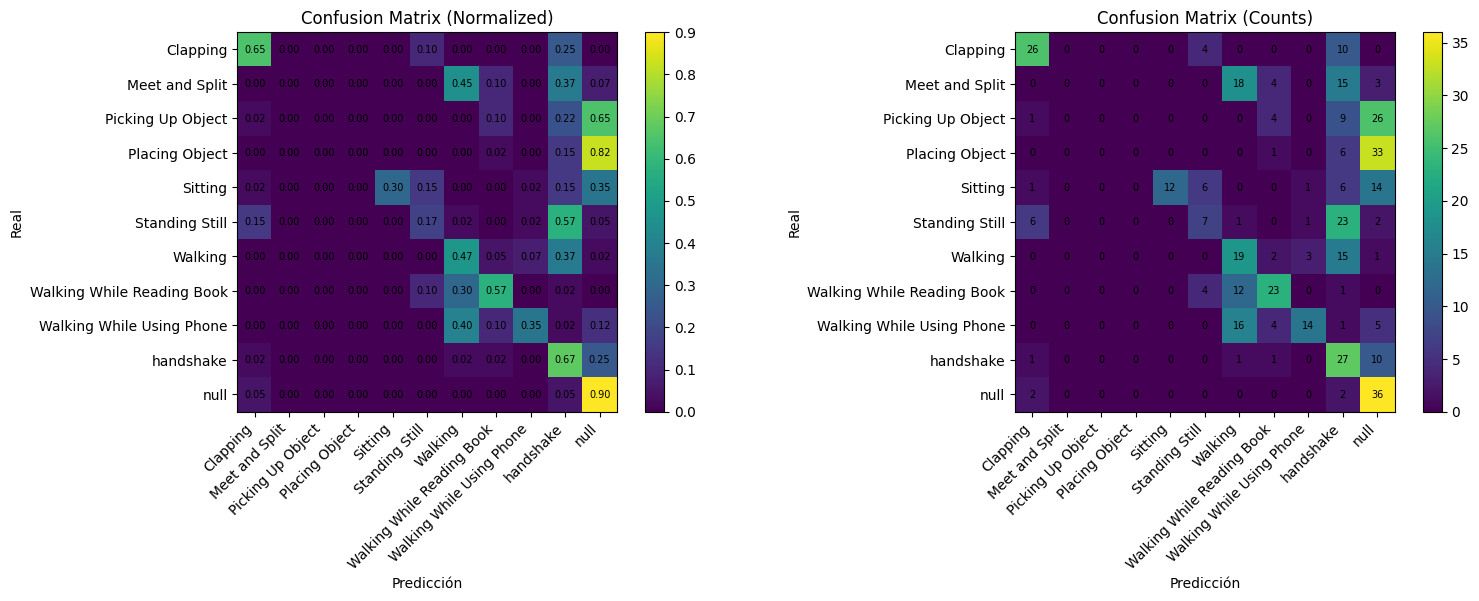

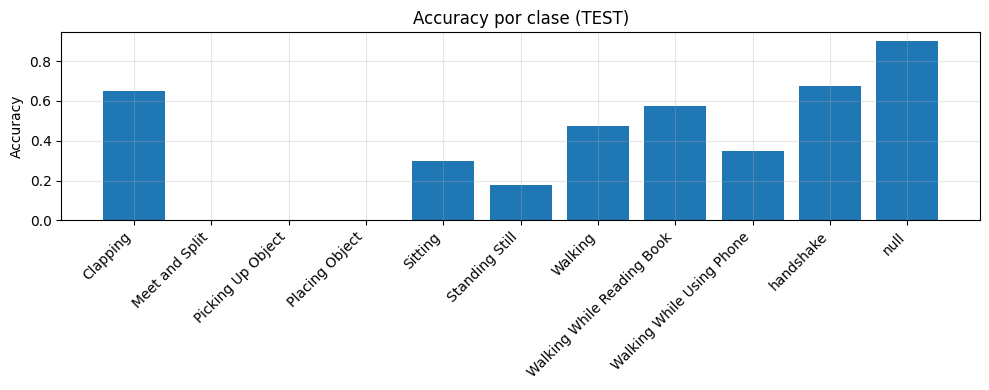

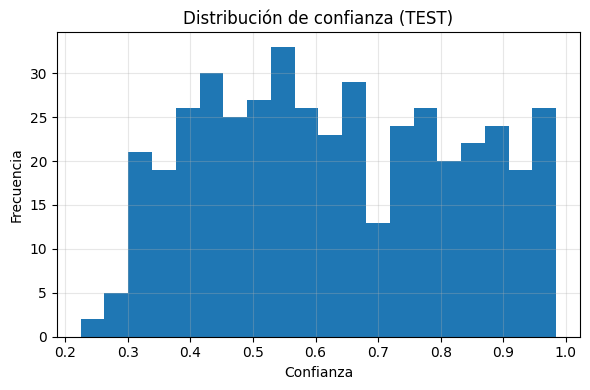


✔ Evaluación completa guardada en: vjepa2_output_32


In [31]:
import numpy as np
import os
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# =========================================================
# EVALUACION EN TEST
# =========================================================
print("\nEvaluando en TEST set...")

best_model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for vids, labels in test_loader:

        
        vids = list(vids)

        inputs = best_processor(vids, return_tensors="pt")
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

        outputs = best_model(**inputs)

        probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()
        preds = outputs.logits.argmax(-1).cpu().numpy()

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# =========================================================
# METRICAS GLOBALES
# =========================================================
acc  = accuracy_score(all_labels, all_preds)
f1   = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
prec = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
rec  = recall_score(all_labels, all_preds, average="weighted", zero_division=0)

print(f"\n{'='*50}")
print("RESULTADOS TEST")
print(f"{'='*50}")
print(f"Accuracy  : {acc:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")

print("\nReporte por clase:")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, zero_division=0))

# =========================================================
# MATRIZ DE CONFUSION
# =========================================================
cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Normalizada
cm_norm = cm.astype(float) / (cm.sum(axis=1)[:, None] + 1e-10)

im0 = axes[0].imshow(cm_norm)
axes[0].set_title("Confusion Matrix (Normalized)")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Real")
axes[0].set_xticks(range(len(CLASS_NAMES)))
axes[0].set_yticks(range(len(CLASS_NAMES)))
axes[0].set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
axes[0].set_yticklabels(CLASS_NAMES)

for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        axes[0].text(j, i, f"{cm_norm[i,j]:.2f}",
                     ha="center", va="center", fontsize=7)

plt.colorbar(im0, ax=axes[0])

# --- Conteos
im1 = axes[1].imshow(cm)
axes[1].set_title("Confusion Matrix (Counts)")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Real")
axes[1].set_xticks(range(len(CLASS_NAMES)))
axes[1].set_yticks(range(len(CLASS_NAMES)))
axes[1].set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
axes[1].set_yticklabels(CLASS_NAMES)

for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        axes[1].text(j, i, f"{cm[i,j]}",
                     ha="center", va="center", fontsize=7)

plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.savefig(os.path.join(CFG["output_dir"], "confusion_matrix_test.png"), dpi=150)
plt.show()

# =========================================================
# ACCURACY POR CLASE
# =========================================================
class_acc = cm.diagonal() / (cm.sum(axis=1) + 1e-10)

plt.figure(figsize=(10, 4))
plt.bar(CLASS_NAMES, class_acc)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Accuracy")
plt.title("Accuracy por clase (TEST)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CFG["output_dir"], "class_accuracy_test.png"), dpi=150)
plt.show()

# =========================================================
# CONFIANZA DEL MODELO
# =========================================================
all_probs = np.array(all_probs)
confidence = all_probs.max(axis=1)

plt.figure(figsize=(6,4))
plt.hist(confidence, bins=20)
plt.title("Distribución de confianza (TEST)")
plt.xlabel("Confianza")
plt.ylabel("Frecuencia")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CFG["output_dir"], "confidence_hist.png"), dpi=150)
plt.show()

print("\n✔ Evaluación completa guardada en:", CFG["output_dir"])

---
## Save Model and Verify Reload


In [ ]:
# El mejor modelo ya se guardó durante el entrenamiento.
# Esta celda verifica que se puede recargar correctamente.

SAVE_PATH = CFG["checkpoint_best"]
print(f"Modelo guardado en: {SAVE_PATH}")
print("Archivos:", os.listdir(SAVE_PATH))

# ── Guardar también una versión final explícita ───────────────────────────
final_path = os.path.join(CFG["output_dir"], "final_model")
best_model.save_pretrained(final_path)
best_processor.save_pretrained(final_path)
print(f"\nModelo final guardado en: {final_path}")

# ── Test de recarga ───────────────────────────────────────────────────────
print("\nVerificando recarga del modelo...")
reload_model = VJEPA2ForVideoClassification.from_pretrained(
    final_path, torch_dtype=torch.float32
).to(DEVICE).eval()
reload_proc  = VJEPA2VideoProcessor.from_pretrained(final_path)

print(f"  Clases del modelo recargado: {list(reload_model.config.id2label.values())}")
print(f"  Parámetros: {sum(p.numel() for p in reload_model.parameters()):,}")
print("\nModelo recargado correctamente")

# Limpiar para liberar VRAM
del reload_model, reload_proc
torch.cuda.empty_cache()

Modelo guardado en: vjepa2_output/best_model
Archivos: ['checkpoint', 'video_preprocessor_config.json', 'model.safetensors', 'config.json']

Modelo final guardado en: vjepa2_output/final_model

Verificando recarga del modelo...
  Clases del modelo recargado: ['Clapping', 'Meet and Split', 'Picking Up Object', 'Placing Object', 'Sitting', 'Standing Still', 'Walking', 'Walking While Reading Book', 'Walking While Using Phone', 'handshake', 'null']
  Parámetros: 375,318,923

Modelo recargado correctamente


---
## Inference on MP4 Video


Inferencia sobre videos de test...

Video                               Real                 Predicción             Conf   OK
------------------------------------------------------------------------------------------
Clapping (101).mp4                  Clapping             Clapping              51.8% ok
Clapping (102).mp4                  Clapping             Clapping              59.1% ok
Clapping (119).mp4                  Clapping             Clapping              98.9% ok
Clapping (121).mp4                  Clapping             Clapping              98.7% ok
Clapping (123).mp4                  Clapping             Clapping             100.0% ok
Clapping (132).mp4                  Clapping             Clapping             100.0% ok
Clapping (136).mp4                  Clapping             Clapping              99.9% ok
Clapping (139).mp4                  Clapping             Clapping             100.0% ok
Clapping (140).mp4                  Clapping             Clapping              

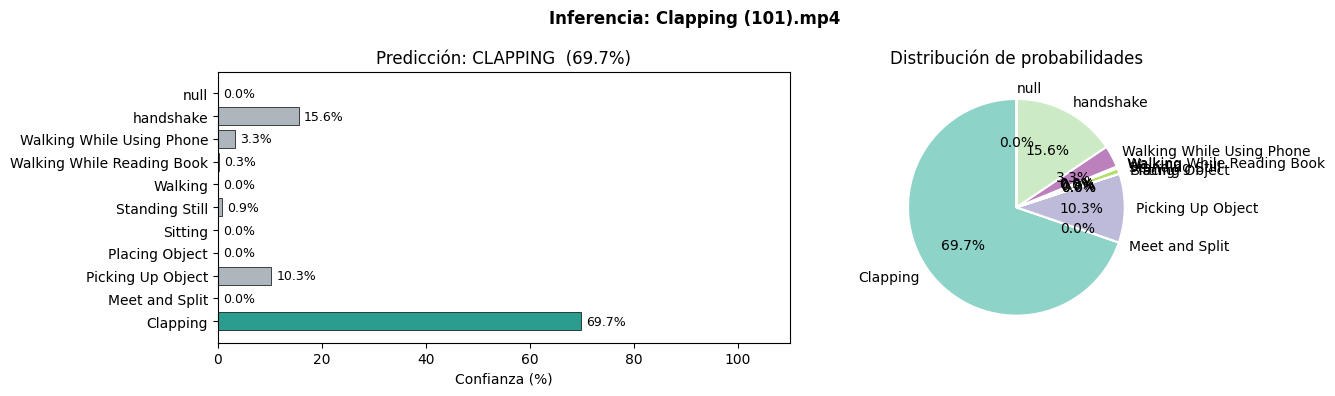

In [ ]:
def infer_video(video_path: str, model, processor, id2label: dict,
                device: str, n_clips: int = 5, frame_gap: int = 3,
                frames_per_clip: int = 16):

    model.eval()
    decoder  = VideoDecoder(video_path)
    all_probs = []

    for _ in range(n_clips):

        clip = clips_at_random_indices(
            decoder,
            num_clips=1,
            num_frames_per_clip=frames_per_clip,
            num_indices_between_frames=frame_gap,
        ).data  # (1, T, C, H, W)

        clip = clip.squeeze(0)  # (T, C, H, W)

        # crop
        H = processor.crop_size["height"]
        W = processor.crop_size["width"]
        clip = v2.CenterCrop((H, W))(clip)

        
        clip = [frame for frame in clip]

        inputs = processor(clip, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            logits = model(**inputs).logits
            probs  = torch.softmax(logits, dim=-1).cpu().numpy()[0]

        all_probs.append(probs)

    avg_probs  = np.mean(all_probs, axis=0)
    pred_idx   = avg_probs.argmax()

    return id2label[pred_idx], avg_probs[pred_idx], avg_probs

def plot_prediction(video_path, pred_label, confidence, avg_probs, class_names):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"Inferencia: {pathlib.Path(video_path).name}",
                 fontsize=12, fontweight="bold")

    # Barras de confianza
    colors = ["#2A9D8F" if c == pred_label else "#ADB5BD" for c in class_names]
    bars = axes[0].barh(class_names, avg_probs * 100, color=colors, edgecolor="black", linewidth=0.5)
    axes[0].set_xlim(0, 110)
    axes[0].set_xlabel("Confianza (%)")
    axes[0].set_title(f"Predicción: {pred_label.upper()}  ({confidence*100:.1f}%)")
    for bar, val in zip(bars, avg_probs):
        axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                     f"{val*100:.1f}%", va="center", fontsize=9)

    # Pie chart
    wedge_colors = plt.cm.Set3(np.linspace(0, 1, len(class_names)))
    axes[1].pie(avg_probs, labels=class_names, autopct="%1.1f%%",
                colors=wedge_colors, startangle=90,
                wedgeprops={"edgecolor": "white", "linewidth": 1.5})
    axes[1].set_title("Distribución de probabilidades")

    plt.tight_layout()
    plt.show()


# ── Probar con todos los videos de test ──────────────────────────────────
print("Inferencia sobre videos de test...\n")
print(f"{'Video':<35} {'Real':<20} {'Predicción':<20} {'Conf':>6} {'OK':>4}")
print("-" * 90)

correct = 0
for path in test_paths[:10]:   # primeros 10 para no tardar demasiado
    true_label = path.parts[-2]
    pred_label, conf, probs = infer_video(
        str(path), best_model, best_processor, ID2LABEL, DEVICE
    )
    ok = "ok" if pred_label == true_label else "bad"
    if pred_label == true_label:
        correct += 1
    print(f"{path.name:<35} {true_label:<20} {pred_label:<20} {conf*100:>5.1f}% {ok}")

n_shown = min(10, len(test_paths))
print(f"\nAcc en muestra: {correct}/{n_shown} = {correct/n_shown:.1%}")

# Visualizar el primer video de test
if test_paths:
    first_video = str(test_paths[0])
    pred_label, conf, probs = infer_video(
        first_video, best_model, best_processor, ID2LABEL, DEVICE
    )
    plot_prediction(first_video, pred_label, conf, probs, CLASS_NAMES)

# VJEPA2.1 Finetuning

In [ ]:
# %% [code]
import os, cv2, math, random, gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.cuda.amp import GradScaler, autocast

torch.backends.cudnn.benchmark = True  #  speedup

In [ ]:
# ----------------------------------------------------------------------
# 1. Helpers 
# ----------------------------------------------------------------------
def trunc_normal_(tensor, mean=0., std=1., a=-2., b=2.):
    with torch.no_grad():
        def norm_cdf(x):
            return (1. + math.erf(x / math.sqrt(2.))) / 2.
        l = norm_cdf((a - mean) / std)
        u = norm_cdf((b - mean) / std)
        tensor.uniform_(2*l-1, 2*u-1)
        tensor.erfinv_()
        tensor.mul_(std*math.sqrt(2.)).add_(mean)
        tensor.clamp_(min=a, max=b)

# ----------------------------------------------------------------------
# 2. MODELO (SIN CAMBIOS)
# ----------------------------------------------------------------------
class PatchEmbed3D(nn.Module):
    def __init__(self, patch_size=16, tubelet_size=2, in_chans=3, embed_dim=768):
        super().__init__()
        self.proj = nn.Conv3d(in_chans, embed_dim,
                              kernel_size=(tubelet_size, patch_size, patch_size),
                              stride=(tubelet_size, patch_size, patch_size))
    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1,2)

class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim*4),
            nn.GELU(),
            nn.Linear(dim*4, dim)
        )
    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

class VJEPA2_1Encoder(nn.Module):
    def __init__(self, num_frames=16, embed_dim=768):
        super().__init__()
        self.patch_embed = PatchEmbed3D()
        self.blocks = nn.ModuleList([TransformerBlock(embed_dim, 12) for _ in range(12)])
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        x = self.patch_embed(x)
        for blk in self.blocks:
            x = blk(x)
        return self.norm(x)

class VJEPA2_1Classifier(nn.Module):
    def __init__(self, encoder, num_classes):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Sequential(
            nn.LayerNorm(768),
            nn.Linear(768, num_classes)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = x.mean(dim=1)
        return self.head(x)

# ----------------------------------------------------------------------
# 3. DATASET 
# ----------------------------------------------------------------------
class HARVideoDataset(Dataset):
    def __init__(self, root, num_frames=16, size=224):
        self.samples = []
        self.classes = sorted(os.listdir(root))
        self.class_to_idx = {c:i for i,c in enumerate(self.classes)}

        for c in self.classes:
            for f in os.listdir(os.path.join(root,c)):
                if f.endswith(".mp4"):
                    self.samples.append((os.path.join(root,c,f), self.class_to_idx[c]))

        self.num_frames = num_frames
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((size,size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485]*3,[0.229]*3)
        ])

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        cap = cv2.VideoCapture(path)

        frames = []
        step = max(1, int(cap.get(cv2.CAP_PROP_FRAME_COUNT)//self.num_frames))

        i=0
        while len(frames) < self.num_frames:
            ret, frame = cap.read()
            if not ret: break
            if i % step == 0:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frames.append(self.transform(frame))
            i+=1

        cap.release()

        while len(frames) < self.num_frames:
            frames.append(frames[-1])

        x = torch.stack(frames).permute(1,0,2,3)
        return x, label

# ----------------------------------------------------------------------
# 4. TRAIN / EVAL 
# ----------------------------------------------------------------------
def train_one_epoch(model, loader, opt, crit, scaler, device):
    model.train()
    total_loss, correct, total = 0,0,0

    for x,y in tqdm(loader):
        x,y = x.to(device), y.to(device)

        with autocast():
            out = model(x)
            loss = crit(out,y)

        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        opt.zero_grad()

        total_loss += loss.item()
        correct += (out.argmax(1)==y).sum().item()
        total += y.size(0)

    return total_loss/len(loader), 100*correct/total

@torch.no_grad()
def evaluate(model, loader, crit, device):
    model.eval()
    total_loss, correct, total = 0,0,0
    preds, labels = [], []

    for x,y in loader:
        x,y = x.to(device), y.to(device)
        out = model(x)
        loss = crit(out,y)

        total_loss += loss.item()
        p = out.argmax(1)

        preds.extend(p.cpu().numpy())
        labels.extend(y.cpu().numpy())

        correct += (p==y).sum().item()
        total += y.size(0)

    return total_loss/len(loader), 100*correct/total, preds, labels


In [ ]:


# ----------------------------------------------------------------------
# 5. MAIN 
# ----------------------------------------------------------------------
def run_har_finetune(data_root, checkpoint_path=None,
                     batch_size=2, epochs=30, lr=1e-4,
                     patience=3, num_workers=4):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    scaler = GradScaler()

    train_ds = HARVideoDataset(os.path.join(data_root,"train"))
    val_ds   = HARVideoDataset(os.path.join(data_root,"val"))
    test_ds  = HARVideoDataset(os.path.join(data_root,"test"))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size)
    test_loader  = DataLoader(test_ds, batch_size=batch_size)

    encoder = VJEPA2_1Encoder()
    model = VJEPA2_1Classifier(encoder, len(train_ds.classes)).to(device)

    #  cargar weights
    if checkpoint_path and os.path.exists(checkpoint_path):
        state = torch.load(checkpoint_path, map_location="cpu")
        model.encoder.load_state_dict(state, strict=False)

    #  congelar 80% (mejora accuracy)
    for name,p in model.encoder.named_parameters():
        if "blocks.10" not in name and "blocks.11" not in name:
            p.requires_grad = False

    opt = optim.AdamW(filter(lambda p:p.requires_grad, model.parameters()), lr=lr)
    crit = nn.CrossEntropyLoss()

    best_acc = 0
    patience_count = 0

    hist = {"train":[], "val":[]}

    for ep in range(epochs):
        print(f"\nEpoch {ep+1}")

        tr_loss,tr_acc = train_one_epoch(model, train_loader, opt, crit, scaler, device)
        val_loss,val_acc,_,_ = evaluate(model, val_loader, crit, device)

        print(f"Train {tr_acc:.2f} | Val {val_acc:.2f}")

        hist["train"].append(tr_acc)
        hist["val"].append(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(),"best.pth")
            patience_count = 0
        else:
            patience_count +=1
            if patience_count>=patience:
                print("Early stopping")
                break

        torch.cuda.empty_cache()
        gc.collect()

    # TEST
    model.load_state_dict(torch.load("best.pth"))
    _, acc, preds, labels = evaluate(model, test_loader, crit, device)

    print("TEST ACC:", acc)
    print(classification_report(labels,preds))

    # MATRIZ
    cm = confusion_matrix(labels,preds)
    plt.imshow(cm)
    plt.title("Confusion Matrix")
    plt.show()

    # CURVAS
    plt.plot(hist["train"], label="train")
    plt.plot(hist["val"], label="val")
    plt.legend()
    plt.title("Convergence")
    plt.show()


Epoch 1


100%|██████████| 74/74 [11:37<00:00,  9.42s/it]


Train 28.41 | Val 44.09

Epoch 2


100%|██████████| 74/74 [11:28<00:00,  9.31s/it]


Train 53.86 | Val 50.00

Epoch 3


...

Train 100.00 | Val 91.82

Epoch 18


100%|██████████| 74/74 [11:55<00:00,  9.67s/it]


Train 100.00 | Val 92.73

Epoch 19


100%|██████████| 74/74 [11:35<00:00,  9.40s/it] 


Train 100.00 | Val 92.27
Early stopping
TEST ACC: 91.81818181818181
              precision    recall  f1-score   support

           0       0.89      0.97      0.93        40
           1       0.81      0.85      0.83        40
           2       1.00      1.00      1.00        40
           3       1.00      1.00      1.00        40
           4       0.94      0.85      0.89        40
           5       1.00      0.93      0.96        40
           6       0.78      0.80      0.79        40
           7       0.95      0.95      0.95        40
           8       0.89      1.00      0.94        40
           9       0.92      0.82      0.87        40
          10       0.95      0.93      0.94        40

    accuracy                           0.92       440
   macro avg       0.92      0.92      0.92       440
weighted avg       0.92      0.92      0.92       440



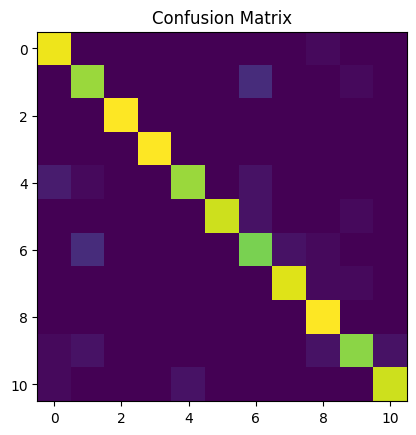

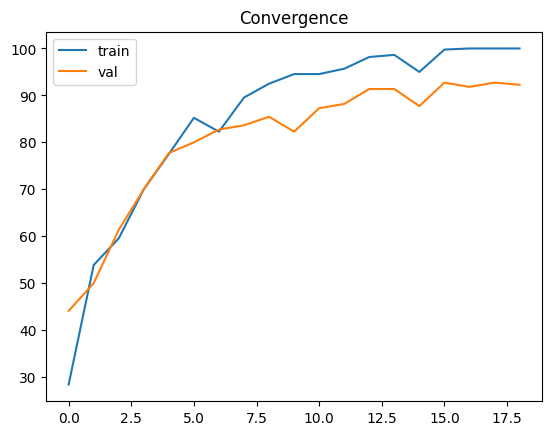

In [2]:
# %% [code]
import warnings
warnings.filterwarnings("ignore")

run_har_finetune(
    data_root="HAR_data",
    checkpoint_path="/model/vjepa2_1_vitb_dist_vitG_384.pt",
    batch_size=6,
    epochs=30,
    lr=1e-4,
    patience=3,
    num_workers=4
)

Real: Clapping | Pred: Clapping | Conf: 1.00
  OK
--------------------------------------------------
Real: Clapping | Pred: Clapping | Conf: 1.00
  OK
--------------------------------------------------
Real: Clapping | Pred: Clapping | Conf: 1.00
  OK
--------------------------------------------------
Real: Clapping | Pred: Clapping | Conf: 1.00
  OK
--------------------------------------------------
Real: Clapping | Pred: Clapping | Conf: 0.98
  OK
--------------------------------------------------
Real: Clapping | Pred: Clapping | Conf: 0.99
  OK
--------------------------------------------------
Real: Clapping | Pred: Clapping | Conf: 0.99
  OK
--------------------------------------------------
Real: Clapping | Pred: Clapping | Conf: 0.95
  OK
--------------------------------------------------
Real: Clapping | Pred: Clapping | Conf: 1.00
  OK
--------------------------------------------------
Real: Clapping | Pred: Clapping | Conf: 1.00
  OK
-----------------------------------------

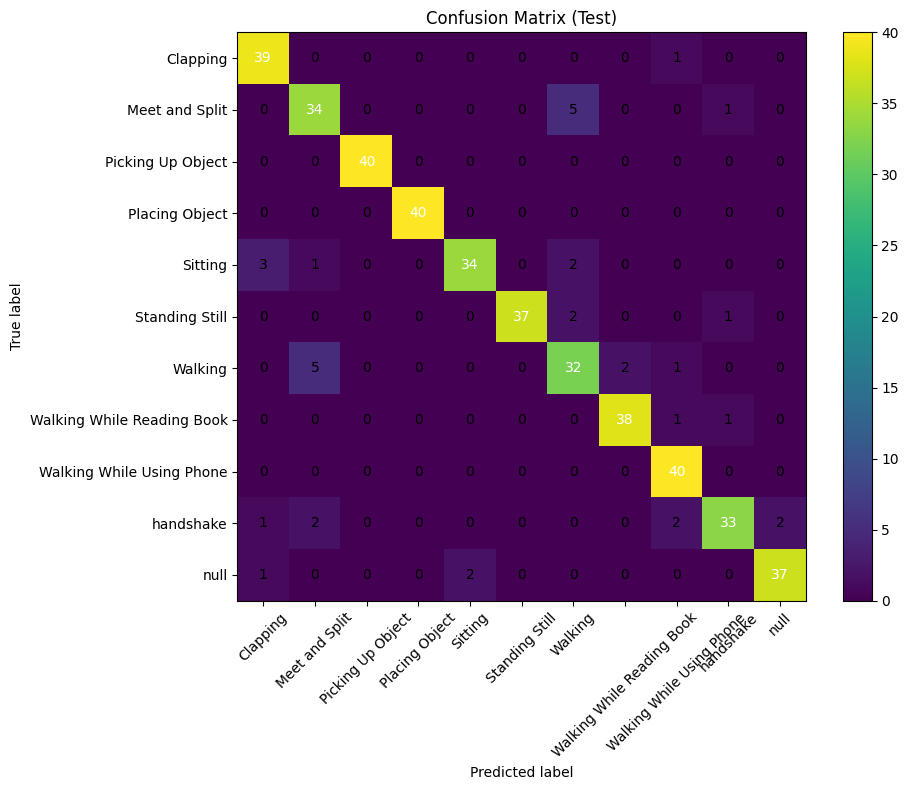

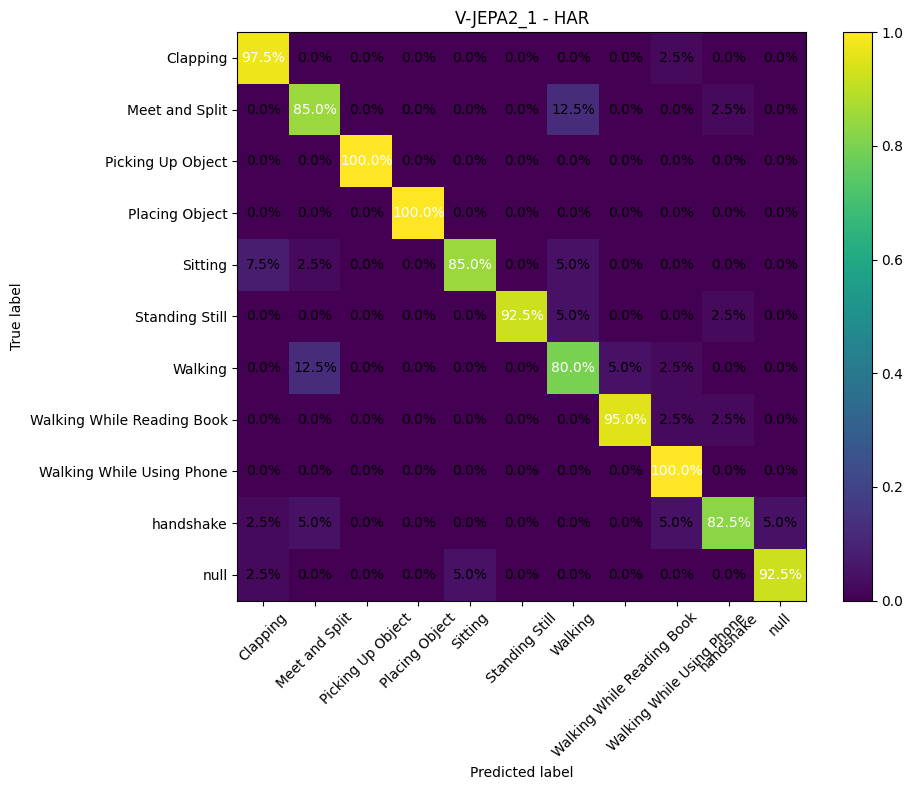

In [12]:
# ----------------------------------------------------------------------
# TEST + MATRIZ DE CONFUSIÓN 
# ----------------------------------------------------------------------
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import torch.nn.functional as F

data_root = "HAR_data"
batch_size = 6
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_ds  = HARVideoDataset(os.path.join(data_root,"test"))

test_loader  = DataLoader(test_ds, batch_size=batch_size)


encoder = VJEPA2_1Encoder()
model = VJEPA2_1Classifier(encoder, num_classes=len(test_ds.classes)).to(device)

# cargar pesos
model.load_state_dict(torch.load("best.pth", map_location=device))
model.eval()

all_preds = []
all_labels = []

#create csv para guardar resultados
import csv
csv_path = "test_predictions.csv"
with open(csv_path, mode='w', newline='') as csv_file:
    writer = csv.writer(csv_file)
    writer.writerow(["Real", "Predicción", "Confianza1", "Confianza2", 
                     "Confianza3", "Confianza4", "Confianza5", "Confianza6", 
                     "Confianza7", "Confianza8", "Confianza9", "Confianza10",
                     "Confianza11", 
                     ])


with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        probs = F.softmax(out, dim=1)

        #save all confidences for csv 1-11 in the csv are 11 folders, and the first two columns are real and predicted labels

        # All confidences summ are 1 for video
        for i in range(probs.size(0)):
            
            video_path = test_ds.samples[i][0] 
            real_label = test_ds.classes[y[i].item()]
            pred_label = test_ds.classes[probs[i].argmax().item()]

            #all confidences add a total of 1 for each video, non max confidences, save all in csv
            confidences = probs.cpu().numpy()
            with open(csv_path, mode='a', newline='') as csv_file:
                writer = csv.writer(csv_file)
                writer.writerow([real_label, pred_label] + confidences[i].tolist())

        # Max confidence and predicted class
        conf, preds = torch.max(probs, dim=1)

        #imprimir predicciones y los nombres del video, y salvarlas en csv para análisis posterior
        for i in range(len(y)):
            print(f"Real: {test_ds.classes[y[i].item()]} | Pred: {test_ds.classes[preds[i].item()]} | Conf: {conf[i].item():.2f}")
           
            #if prediction is correct
            print(f"  {'OK' if preds[i].item() == y[i].item() else 'BAD'}")
            print("-" * 50)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# métricas
print("TEST REPORT:")
print(classification_report(all_labels, all_preds, target_names=test_ds.classes))

# matriz de confusión
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap="viridis")  # morado-amarillo
plt.title("Confusion Matrix (Test)")
plt.colorbar()

tick_marks = np.arange(len(test_ds.classes))
plt.xticks(tick_marks, test_ds.classes, rotation=45)
plt.yticks(tick_marks, test_ds.classes)

plt.ylabel("True label")
plt.xlabel("Predicted label")

# números dentro de la matriz
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black")

plt.tight_layout()
plt.savefig("confusion_matrix_test.png", dpi=300)
plt.show()


#matriz con porcentajes
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(10, 8))
plt.imshow(cm_norm, cmap="viridis")
plt.title("V-JEPA2_1 - HAR")
plt.colorbar()
plt.xticks(tick_marks, test_ds.classes, rotation=45)
plt.yticks(tick_marks, test_ds.classes)
plt.ylabel("True label")
plt.xlabel("Predicted label")
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        plt.text(j, i, f"{cm_norm[i, j]*100:.1f}%",
                 ha="center", va="center",
                 color="white" if cm_norm[i, j] > 0.5 else "black")
plt.tight_layout()
plt.savefig("confusion_matrix_test_normalized.png", dpi=300)
plt.show()


TEST REPORT:
                            precision    recall  f1-score   support

                  Clapping       0.89      0.97      0.93        40
            Meet and Split       0.81      0.85      0.83        40
         Picking Up Object       1.00      1.00      1.00        40
            Placing Object       1.00      1.00      1.00        40
                   Sitting       0.94      0.85      0.89        40
            Standing Still       1.00      0.93      0.96        40
                   Walking       0.78      0.80      0.79        40
Walking While Reading Book       0.95      0.95      0.95        40
 Walking While Using Phone       0.89      1.00      0.94        40
                 handshake       0.92      0.82      0.87        40
                      null       0.95      0.93      0.94        40

                  accuracy                           0.92       440
                 macro avg       0.92      0.92      0.92       440
              weighted avg       

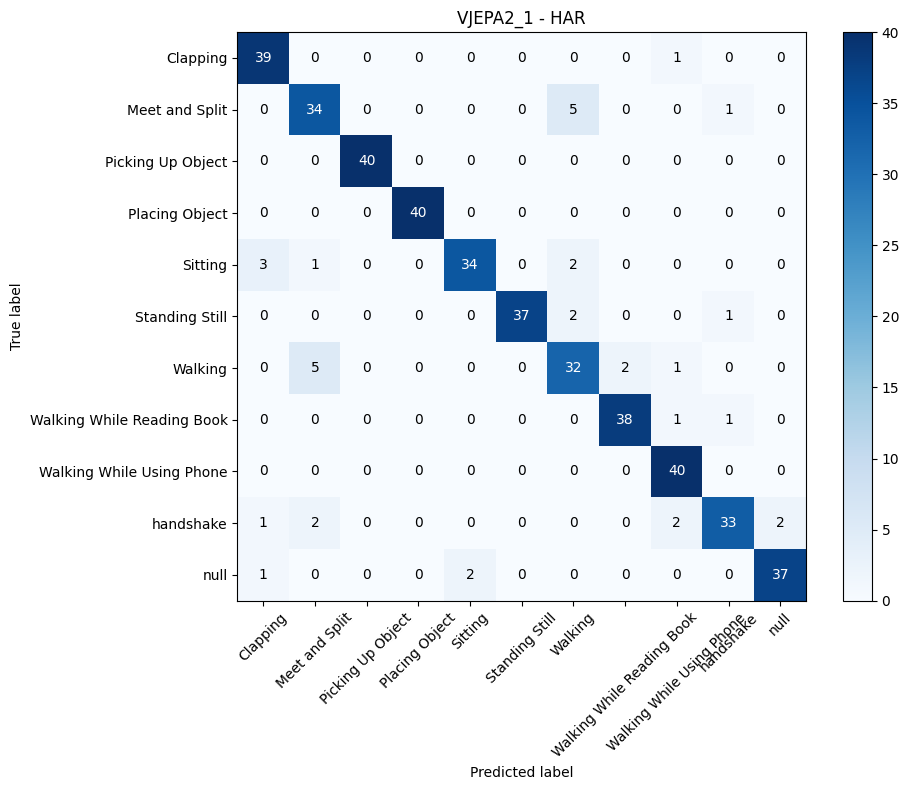

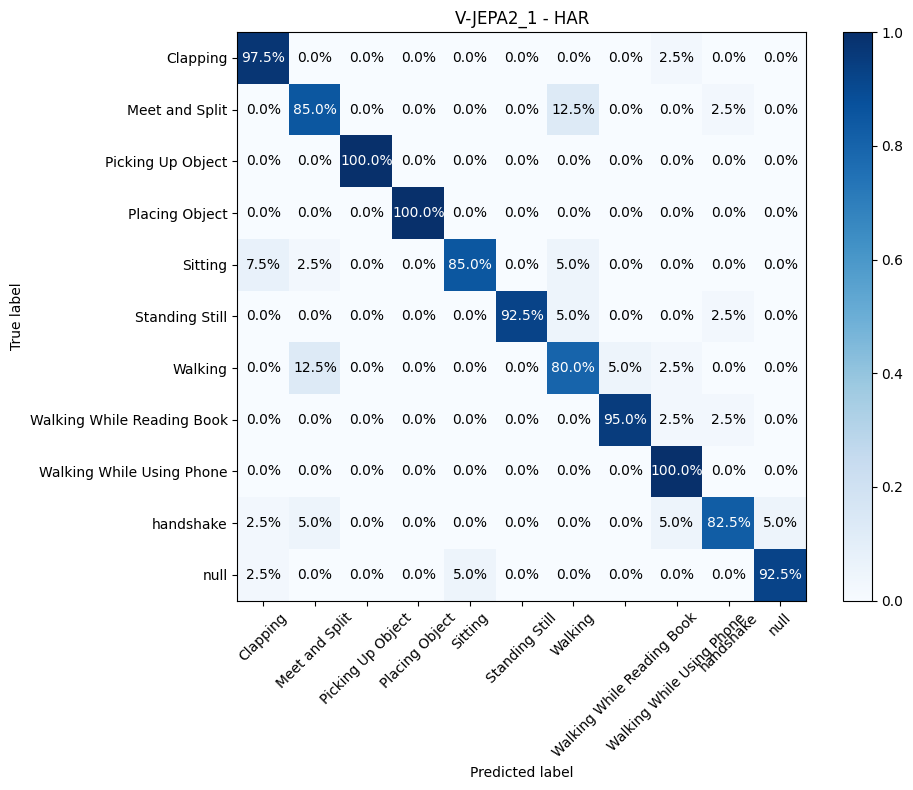

In [15]:
# métricas
print("TEST REPORT:")
print(classification_report(all_labels, all_preds, target_names=test_ds.classes))

# matriz de confusión
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap="Blues")  
plt.title("VJEPA2_1 - HAR")
plt.colorbar()

tick_marks = np.arange(len(test_ds.classes))
plt.xticks(tick_marks, test_ds.classes, rotation=45)
plt.yticks(tick_marks, test_ds.classes)

plt.ylabel("True label")
plt.xlabel("Predicted label")

# números dentro de la matriz
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black")

plt.tight_layout()
plt.savefig("vjepa2_1_count.png", dpi=300)
plt.show()


#matriz con porcentajes
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(10, 8))
plt.imshow(cm_norm, cmap="Blues")
plt.title("V-JEPA2_1 - HAR")
plt.colorbar()
plt.xticks(tick_marks, test_ds.classes, rotation=45)
plt.yticks(tick_marks, test_ds.classes)
plt.ylabel("True label")
plt.xlabel("Predicted label")
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        plt.text(j, i, f"{cm_norm[i, j]*100:.1f}%",
                 ha="center", va="center",
                 color="white" if cm_norm[i, j] > 0.5 else "black")
plt.tight_layout()
plt.savefig("vjepa2_1_normalized.png", dpi=300)
plt.show()

### Examples


(np.float64(-0.5), np.float64(2091.5), np.float64(559.5), np.float64(-0.5))

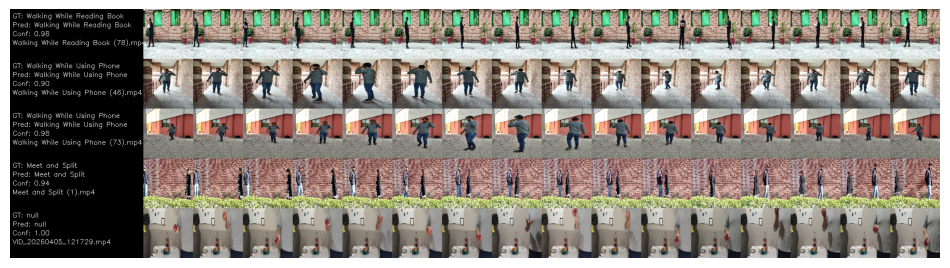

In [1]:
#plot the image timeline.png
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread("timeline.png")
plt.figure(figsize=(12, 6))
plt.imshow(img)
plt.axis('off')

In [7]:
# csv test_predictions_vjepa2_1.csv
import pandas as pd
df = pd.read_csv("test_predictions_vjepa2.1.csv")
df.head(80)

,Real,Predicción,Confianza1,Confianza2,Confianza3,Confianza4,Confianza5,Confianza6,Confianza7,Confianza8,Confianza9,Confianza10,Confianza11
0,Clapping,Clapping,0.999559,0.000005,0.000229,0.000022,0.000112,2.093661e-05,0.000013,3.681913e-07,9.165891e-09,0.000036,3.879660e-06
1,Clapping,Clapping,0.996700,0.000069,0.000400,0.000018,0.000564,1.125418e-06,0.000001,1.134296e-03,5.347015e-07,0.000594,5.193492e-04
2,Clapping,Clapping,0.999811,0.000003,0.000003,0.000002,0.000060,1.664588e-06,0.000090,1.009748e-07,1.655161e-07,0.000029,3.194992e-07
3,Clapping,Clapping,0.999547,0.000005,0.000260,0.000023,0.000088,1.291400e-05,0.000011,3.097899e-07,1.157998e-08,0.000049,4.900813e-06
4,Clapping,Clapping,0.976196,0.000207,0.000164,0.000056,0.012701,5.863026e-05,0.000172,6.034865e-07,4.519718e-06,0.010324,1.176320e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,Meet and Split,Meet and Split,0.028583,0.910302,0.000045,0.000067,0.000331,5.844977e-05,0.000050,1.541327e-04,5.578789e-07,0.060339,6.927618e-05
76,Meet and Split,Meet and Split,0.000003,0.995967,0.000004,0.000014,0.000038,2.239719e-05,0.000149,2.317069e-07,1.415638e-03,0.002272,1.158484e-04
77,Meet and Split,Meet and Split,0.000069,0.998982,0.000002,0.000015,0.000005,1.151559e-05,0.000689,1.852461e-06,1.966984e-06,0.000222,7.042303e-07
78,Meet and Split,Walking,0.001016,0.221141,0.000018,0.000306,0.000024,9.335057e-04,0.770869,2.340248e-03,2.793600e-03,0.000497,6.243160e-05


# Resultados

The VJEPA2.1 model achieves 91.8% accuracy on unseen data, with a decent confusion matrix but room for improvement in underperforming classes.

![Confusion Matrix](vjepa2_1_matrix_confusion.png)

The overall accuracy is strong, but some classes like *meet_and_split* show lower performance and could benefit from more training data.


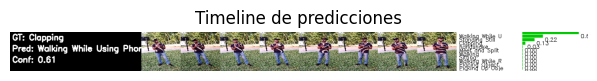

In [ ]:
# /outputs/bad/Clapping/barplots/Clapping (83).png
# outputs/bad/Clapping/timelines/Clapping (83).png

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
video_name = "Clapping (83).mp4"
img2 = mpimg.imread(f"outputs/bad/Clapping/timelines/{video_name.replace('.mp4','.png')}")
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 2)
plt.imshow(img2)
plt.title("Timeline de predicciones")
plt.axis('off')
plt.tight_layout()
plt.savefig(f"outputs/bad/Clapping/analysis_{video_name.replace('.mp4','.png')}", dpi=300)
plt.show()


The 91.82% accuracy is misleading because that remaining 8% contains some classes that are not correctly predicted at all.

| Class | Accuracy | Samples |
|-------|-----------|---------|
| clapping | 100% | 11 |
| meet_and_split | 80% | 10 |
| sitting | 100% | 12 |
| still | 100% | 12 |
| walking | 100% | 14 |

The model performs well on static or distinctive activities, but *meet_and_split* needs improvement.
